(600, 10)


/tmp/ipykernel_4309/1717117322.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_restaurants.values, y=top_restaurants.index, palette='viridis')


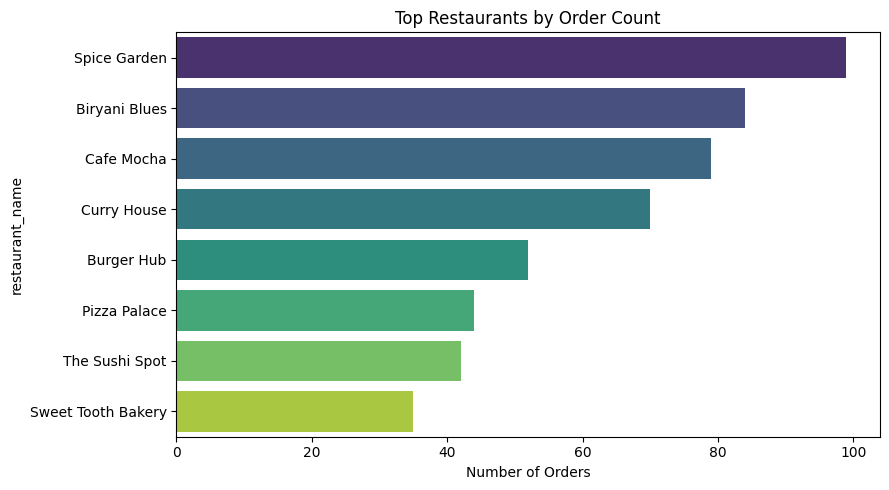

/tmp/ipykernel_4309/1717117322.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cuisine_value.index, y=cuisine_value.values, palette='flare')


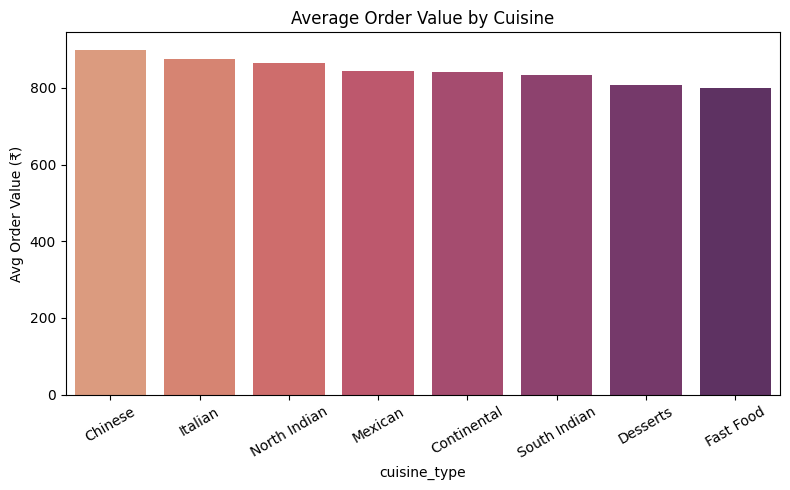

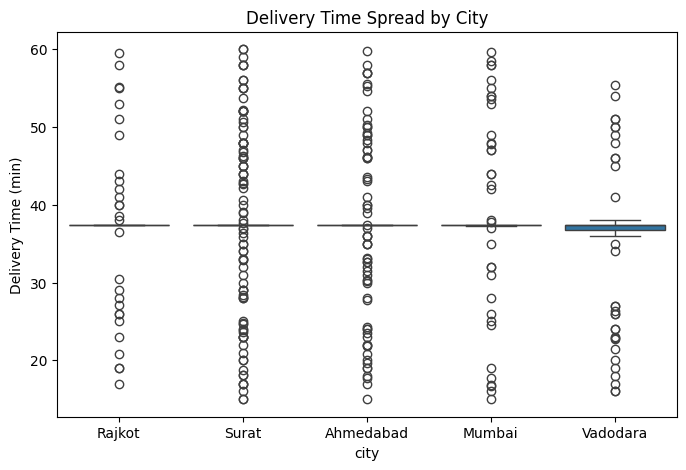

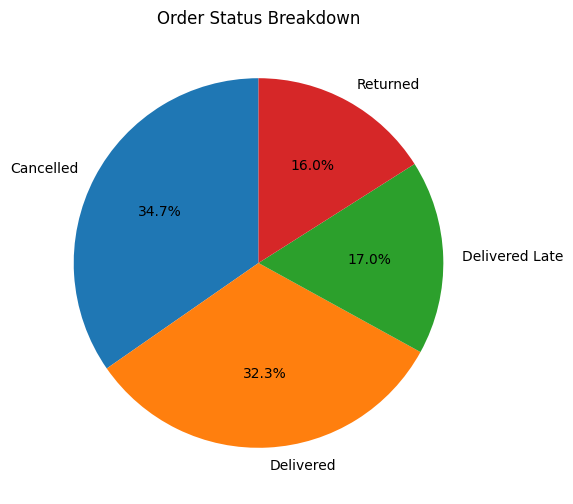

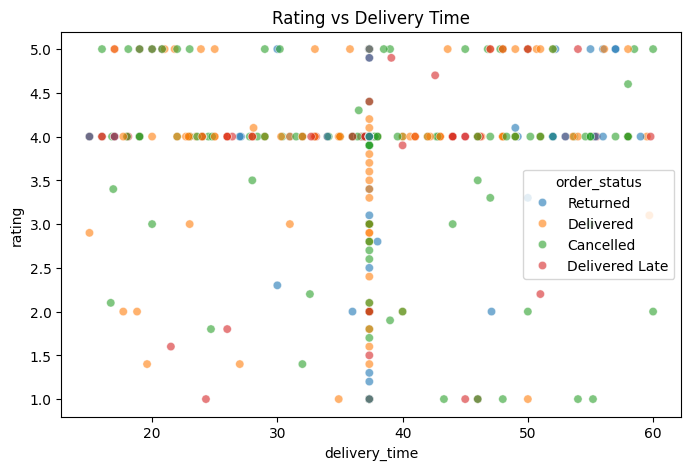

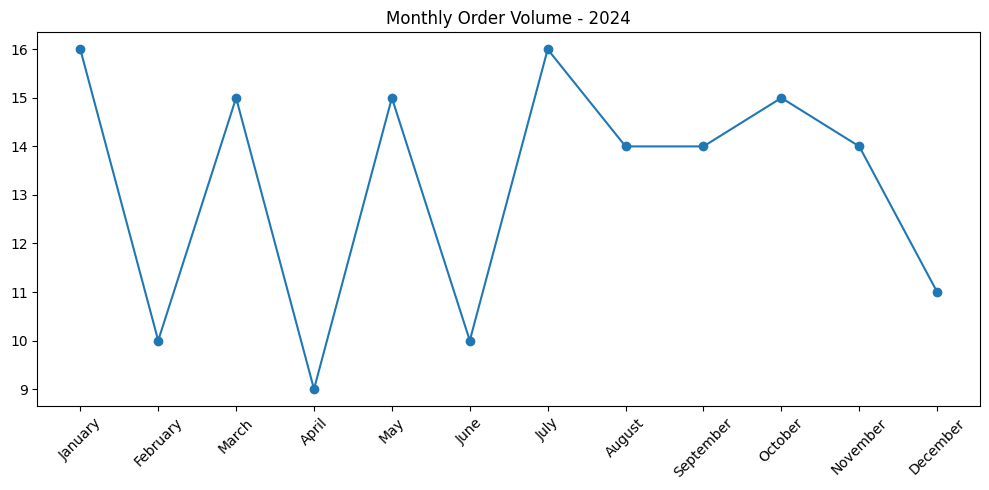

In [49]:
from os import replace
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('food_delivery_data.csv')
#print(df.isna().sum())
#df.info()


for col in ['restaurant_name','cuisine_type','city','order_status']:
  df[col]= df[col].str.strip().str.title()
#print(df['restaurant_name'].unique())
#print(df['cuisine_type'].unique())
#print(df['city'].unique())
#print(df['order_status'].unique())
df['payment_method']=df['payment_method'].replace(['cod','Cash on Delivery'],'COD')
df['payment_method']=df['payment_method'].replace('upi','UPI')
#print(df['payment_method'].unique())

df['delivery_time']=df['delivery_time'].str.replace('min','',regex=False)
df['delivery_time']=df['delivery_time'].str.replace('s','',regex=False)
df['delivery_time']=df['delivery_time'].str.strip()

df['delivery_time']=df['delivery_time'].replace(['', 'N/A'],pd.NA)
df['delivery_time']=pd.to_numeric(df['delivery_time'])
df.describe()

df.loc[(df['delivery_time']<0)|(df['delivery_time']>90),'delivery_time']=pd.NA
#print(df['delivery_time'].isna().sum())

df['delivery_time']=df['delivery_time'].fillna(df['delivery_time'].mean())
#print(df['delivery_time'].unique())

df['order_value']=df['order_value'].str.replace('₹','')
df['order_value']=df['order_value'].str.replace(',','')
df['order_value']=df['order_value'].str.replace('/-','')
df['order_value']=df['order_value'].str.replace('Rs.','')
df['order_value']=df['order_value'].replace(['','N/A'],pd.NA)
df['order_value']=pd.to_numeric(df['order_value'])

df['order_value'].describe()
df['order_value']=df['order_value'].fillna(df['order_value'].median())
#print(df['order_value'].isna().sum())
#print(df['order_value'].unique())

df['rating'] = df['rating'].str.replace(' stars', '', regex=False)
df['rating'] = df['rating'].replace(['NA', ''], pd.NA)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df.loc[df['rating'] == 0, 'rating'] = pd.NA
#print(df['rating'].isna().sum())
df['rating'] = df['rating'].fillna(df['rating'].median())

df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', dayfirst=True)
#print(df['order_date'].isna().sum())
#print(df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)

#Which restaurants get the most orders?
top_restaurants = df['restaurant_name'].value_counts().head(8)

plt.figure(figsize=(9,5))
sns.barplot(x=top_restaurants.values, y=top_restaurants.index, palette='viridis')
plt.title("Top Restaurants by Order Count")
plt.xlabel("Number of Orders")
plt.tight_layout()
plt.show()

#Which restaurants get the most orders?
cuisine_value = df.groupby('cuisine_type')['order_value'].mean().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cuisine_value.index, y=cuisine_value.values, palette='flare')
plt.title("Average Order Value by Cuisine")
plt.ylabel("Avg Order Value (₹)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

#Delivery time distribution — and does it vary by city?
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='city', y='delivery_time')
plt.title("Delivery Time Spread by City")
plt.ylabel("Delivery Time (min)")
plt.show()

 #Order status breakdown — what % get cancelled/returned?

status_counts = df['order_status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
plt.title("Order Status Breakdown")
plt.show()

#Rating vs delivery time — is slower delivery linked to worse ratings?
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='delivery_time', y='rating', hue='order_status', alpha=0.6)
plt.title("Rating vs Delivery Time")
plt.show()


#Monthly order volume trend:
df['month'] = df['order_date'].dt.month_name()
df['month_num'] = df['order_date'].dt.month
monthly_orders = df.groupby(['month_num','month']).size().reset_index(name='order_count').sort_values('month_num')

plt.figure(figsize=(10,5))
plt.plot(monthly_orders['month'], monthly_orders['order_count'], marker='o')
plt.title("Monthly Order Volume - 2024")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()






